# Minggu 4 — Titanic Survival Prediction (Classification)

Setup, W&B & Data Loading

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import wandb

# =========================
# 1) Inisialisasi W&B
# =========================
run = wandb.init(
    project="titanic-classification",
    name="logreg-baseline"
)

# =========================
# 2) Load dataset Titanic (dari Cloud / GitHub)
# Dataset format Kaggle train.csv (891 baris)
# =========================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Cek Keseimbangan Kelas & Split Data

Kita akan memprediksi kolom **Survived** (0 = Meninggal, 1 = Selamat).

Missing values per kolom (sebelum cleaning):


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Missing values per kolom (setelah cleaning):


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


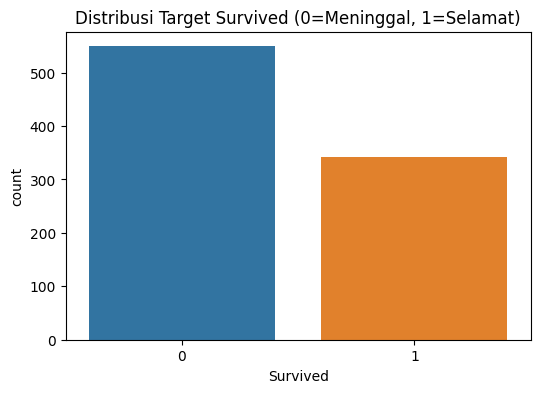

In [17]:
# =========================
# 3) Data Cleaning (mengikuti Minggu 2)
# - Imputasi Age (median)
# - Imputasi Embarked (modus)
# - Drop Cabin (missing terlalu banyak)
# - Encoding Sex & Embarked
# - Feature engineering: FamilySize
# =========================

# Missing value check singkat
print("Missing values per kolom (sebelum cleaning):")
display(df.isnull().sum())

# Imputasi Age dengan median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Imputasi Embarked dengan modus
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin karena terlalu banyak missing
df = df.drop(columns=["Cabin"])

# Encoding Sex: male=0, female=1
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Encoding Embarked (kategori jadi angka)
df["Embarked"] = df["Embarked"].astype("category").cat.codes

# Feature Engineering: FamilySize
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("\nMissing values per kolom (setelah cleaning):")
display(df.isnull().sum())

# Log contoh data bersih ke W&B Table (100 baris)
wandb.log({"clean_data_sample": wandb.Table(dataframe=df.head(100))})

# =========================
# 4) Cek keseimbangan kelas target
# =========================
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived", hue="Survived", legend=False)
plt.title("Distribusi Target Survived (0=Meninggal, 1=Selamat)")
plt.show()

# =========================
# 5) Pisahkan fitur & target
# =========================
# Pakai fitur numerik yang umum dipakai untuk Titanic (versi sederhana)
feature_cols = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "FamilySize"]
X = df[feature_cols]
y = df["Survived"]

# Split Data: 80% Train, 20% Test (pakai stratify supaya proporsi kelas mirip)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

wandb.config.update({
    "test_size": 0.2,
    "random_state": 42,
    "features": feature_cols
})

## Training Model Logistic Regression

In [18]:
# =========================
# 6) Training Logistic Regression
# NOTE: kita pakai StandardScaler supaya fitur skala besar (misalnya Fare) tidak mendominasi
# =========================

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
print("Training selesai!")

Training selesai!


## Prediksi & Evaluasi Metrik

Kita hitung Accuracy, Precision, Recall, dan F1-Score.

In [19]:
# =========================
# 7) Prediksi & Evaluasi
# =========================
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

wandb.log({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1_Score": f1
})

print("--- Hasil Evaluasi Model (Titanic) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

--- Hasil Evaluasi Model (Titanic) ---
Accuracy : 0.7989
Precision: 0.7797
Recall   : 0.6667
F1-Score : 0.7188

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



## Confusion Matrix

Confusion Matrix membantu melihat berapa prediksi yang benar/salah untuk tiap kelas.

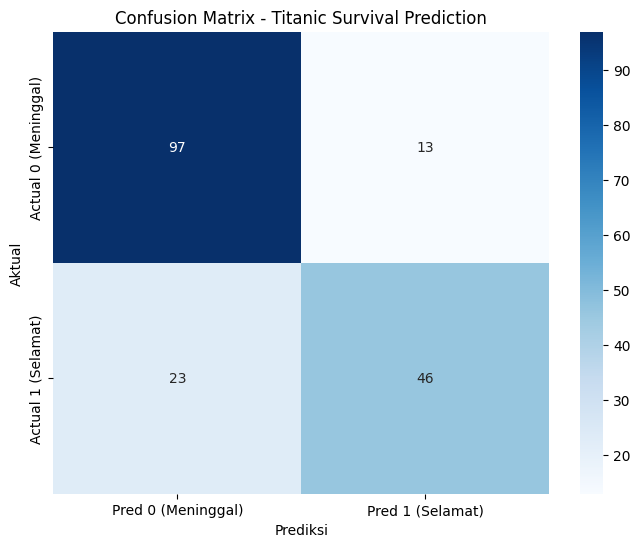

Accuracy,▁
F1_Score,▁
Precision,▁
Recall,▁
Accuracy,0.79888
F1_Score,0.71875
Precision,0.77966
Recall,0.66667


In [20]:
# =========================
# 8) Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred 0 (Meninggal)", "Pred 1 (Selamat)"],
    yticklabels=["Actual 0 (Meninggal)", "Actual 1 (Selamat)"],
    ax=ax
)
ax.set_title("Confusion Matrix - Titanic Survival Prediction")
ax.set_ylabel("Aktual")
ax.set_xlabel("Prediksi")

# Log confusion matrix image ke W&B
wandb.log({"confusion_matrix": wandb.Image(fig)})

plt.show()
wandb.finish()